In [1]:
import Symbolics as Sym
using Nemo
using Statistics
using Distributions
using Combinatorics
using Random
using DataFrames
using Plots
using Latexify

import probability: prob, event_occurency, datas, ranks, face_cards, numbers

# Probability Everywhere

## Lecture 12

In this lecture we’re going to follow a road that often leads to interesting
ideas, and that is the road of trying to understand what appears to be
a paradoxical kind of situation; and then in thinking it through, we
develop an idea.

In [324]:
Sym.@variables a b p C X x d n k λ Ω μ σ α β; #use sets for events and prob space omega
Sym.@variables P(X ~ k) ƒ(x, μ, σ) Pr(X ~ k) logit(x);
Random.seed!(123) # Setting the seed

TaskLocalRNG()

### Two envelopes paradox.

Here is a conundrum known as the two envelopes problem: You are given
two envelopes and told that each envelope contains a check for a certain
amount of money, and one of the checks is for exactly twice as much money
as the other. You randomly select one of the envelopes and open it. The
enclosed check is for a certain amount of money, say d dollars. Now you can
either keep that money, or you can take the contents of the other envelope.
You know that you are as likely to have chosen the lesser amount as you are
likely to have chosen the greater amount. But now you do an expected-value
analysis and nd a paradoxical situation.

There is a 0.5 probability that you have the higher amount and a 0.5
probability that you have the lower amount; thus, the expected value of
switching is:

In [235]:
1//2 * (2d) + 1//2 * d//2 ~ d + d//4 ~ 5//4 * d

(5//4)*d ~ (5//4)*d ~ (5//4)*d

The result is greater than d, so this analysis seems to suggest that you should
switch. But this makes no sense, because it is clearly as likely that you have
the lower amount as the greater amount. What is wrong? The two envelopes
problem brings up a situation we have not dealt with much, namely, one in
which the experiment has in nitely many possible outcomes.

How can we
revise our thinking to cope with in nitely many alternatives?

If any amount of money is possible, then there are in nitely many possibilities
theoretically. But in reality, huge numbers are not possible. Actually, we
have an a priori sense—an expectation—of a probability distribution. We
can hearken back to the Bayesian strategy and realize that we have an a
priori sense of the probabilities of various amounts.

### St. Petersburg paradox.

Another famous paradox involved with gambling is the St. Petersburg
paradox. Suppose a gambler plays a coin- ipping game, winning $2 for
ipping heads. If the gambler ips tails, then heads, he wins $4. If the
gambler ips two tails in a row, then heads, he wins $8. If the gambler is
very lucky, he might ip ve tails in a row, followed by heads, to win $64.
How much would you pay to play this game?

We can calculate the expected value:

In [4]:
1//2 * 2 + 1//4 + 4 + 1//8 * 8 + 1//16 + Inf ~ 1 + 1 + 1 + Inf ~ Inf 

Inf ~ Inf ~ Inf

The expected payout is in nity, so it appears you should pay any amount of
money to play this game. The paradox is that you would not make a great
deal of money in this game. Simulations show that average payoffs are
quite low.

Probability predictions are the basis of statistical inference. Statistical
inferences boil down to comparing expectations from probability with
collected data. If your expectation from probabilistic analysis differs greatly
from what you see in the data, you can make the deduction that the concept
you had about how the data were being produced must be wrong.

**Randomness and uncertainty are fundamental parts of reality. Probability
describes what we should expect from randomness. Probability is a basic
tool for making sense of and coping with the reality of randomness and
uncertainty in our world.**

## The probability density functions PDF(): Discrete



### Normal distributions

In [24]:
ƒ ~ 1//√(2*π*σ^2) * exp(- (x - μ)^2 // 2σ^2)

ƒ(x, μ, σ) ~ exp((-((x - μ)^2)) / (2(σ^2))) / sqrt(6.283185307179586(σ^2))

In [5]:
dist = Normal()

Normal{Float64}(μ=0.0, σ=1.0)

In [6]:
mean(dist)

0.0

In [28]:
xs = rand(dist, 1000)

1000-element Vector{Float64}:
  0.8082879284649668
 -1.1220725081141734
 -1.1046361023292959
 -0.4169926351649334
  0.28758798062385577
  0.2298186980518676
 -0.4217686643996927
 -1.355590621101197
  0.0694591410918936
 -0.11732280453081337
  ⋮
 -0.9054384415976374
  1.8480179360554947
 -1.298457080571386
  0.5967225756464682
  0.43195593259853066
 -0.7970966385937522
 -0.06253190718252355
 -1.2505328746000024
 -0.3463702447057351

In [8]:
quantile.(Normal(), [0.25, 0.75])

2-element Vector{Float64}:
 -0.6744897501960818
  0.6744897501960818

In [9]:
rand(Normal(1, 2), 100)

100-element Vector{Float64}:
  0.6548091874305054
  2.3847939641735145
  1.0393183538295292
  0.9999986165077756
  1.524938980339276
  4.00945316961635
  1.9245488268587665
  0.8462429705141513
  3.663967361777485
  0.897619562809264
  ⋮
  0.025658981498790867
  1.0414038996004922
 -0.12446266435854692
  5.65631672913287
  0.38101533606686855
  0.22543162939725436
 -1.2334207332913332
  2.006158798429646
  3.122893383826189

In [29]:
fit(Normal, xs)

Normal{Float64}(μ=-0.050027717988504805, σ=0.985746575970847)

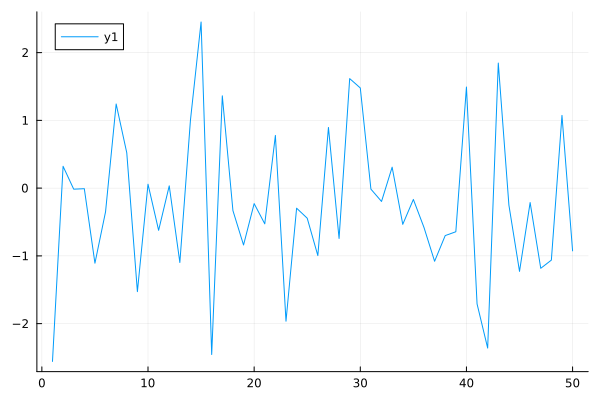

In [370]:
plot(rand(Normal(-0.050027717988504805, 0.985746575970847), 50))

### Binomial distributions 

In [20]:
P ~ (n//k)p^k * (1 - p)^(n-k)

P(X ~ k) ~ (n*((1 - p)^(-k + n))*(p^k)) / k

In [11]:
dice = rand(Binomial(6, .5), 6)

6-element Vector{Int64}:
 4
 3
 2
 3
 3
 2

### Bernoulli distributions

In [44]:
P ~ [ 1 - p,  k ~ 0, p, k ~ 1]

P(X ~ k) ~ Any[1 - p, k ~ 0, p, k ~ 1]

In [83]:
coin = rand(Bernoulli(), 3)

3-element Vector{Bool}:
 1
 0
 0

In [84]:
fit(Bernoulli, coin)

Bernoulli{Float64}(p=0.3333333333333333)

The Benoulli distribution is very similiar to a Binomial with n value = 1 as it is simulated here bellow:

In [87]:
rand(Binomial(1, .5), 3)

3-element Vector{Int64}:
 1
 0
 0

### Poisson distribution

In [303]:
Sym.@variables ƒ(k, λ);

In [97]:
ƒ ~ Pr ~ λ^k * ℯ^(-λ) // factorial(k)

ƒ(k, λ) ~ Pr(X ~ k) ~ ((λ^k)*exp(-λ)) / factorial(k)

In [230]:
buss_arrived = rand(Poisson(1), 5)

5-element Vector{Int64}:
 2
 1
 0
 0
 0

In [231]:
fit(Poisson, buss_arrived)

Poisson{Float64}(λ=0.6)

## The probability density functions PDF(): Continuous.



### Beta distribution

In [304]:
Sym.@variables ƒ(x, α, β);

In [305]:
ƒ ~ C * x^(α - 1)*(1 - x)^(β - 1)

ƒ(x, α, β) ~ C*((1 - x)^(-1 + β))*(x^(-1 + α))

In [306]:
fieldnames(Beta)

(:α, :β)

In [307]:
rand(Beta(), 10)

10-element Vector{Float64}:
 0.933839534828823
 0.3875620365803277
 0.5901704176715852
 0.7314577211776634
 0.43225746201232207
 0.21329068900365966
 0.7453669036667651
 0.03387762973158182
 0.6399798994744701
 0.8279130248053126

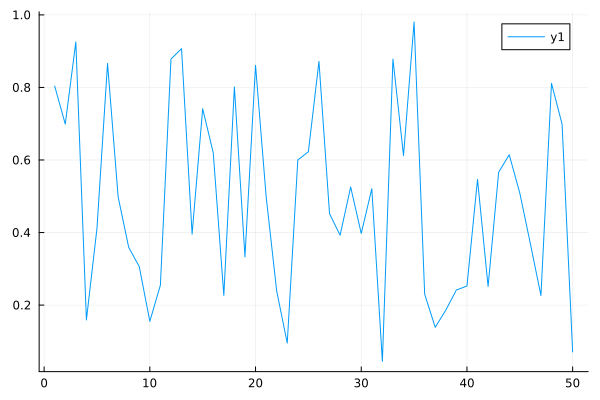

In [366]:
plot(rand(Beta(2, 2), 50))

### Uniform distribution


In [309]:
Sym.@variables ƒ(x, a, b);

In [310]:
ƒ ~ 1//(b - a), a <= x, x <= b

ƒ(x, a, b) ~ (1 / (-a + b), a <= x, x <= b)

In [311]:
fieldnames(Uniform)

(:a, :b)

In [312]:
rand(Uniform(0, 1), 10)

10-element Vector{Float64}:
 0.7620905831365863
 0.13530746161441198
 0.10577786642321496
 0.2557452787258565
 0.6955723975226357
 0.9430786299735574
 0.09870953576518493
 0.22909378484566068
 0.6058182962233329
 0.6391469322395029

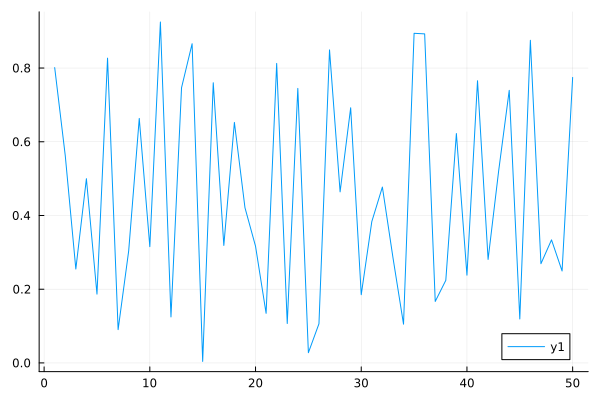

In [365]:
plot(rand(Uniform(0, 1), 50))

### Cauchy distribution


In [314]:
Sym.@variables ƒ(x, μ, σ);

In [323]:
ƒ ~ 1//(π*σ*(1 + ((x - μ)//σ)^2))

ƒ(x, μ, σ) ~ 1 / (3.141592653589793(1 + ((x - μ) / σ)^2)*σ)

In [318]:
rand(Cauchy(), 10)

10-element Vector{Float64}:
 16.282085404661874
  0.5641435768297329
  1.1474768935123008
  0.6392705270723077
  0.9333748349501201
 -2.189276496514382
  6.144492086169357
  0.4699900344765831
  1.1828098100693634
 -1.4902840149039533

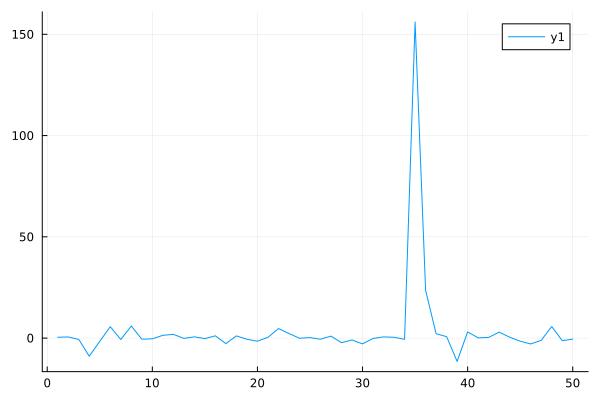

In [364]:
plot(rand(Cauchy(), 50))

### Logit-normal distribution


In [338]:
latexify("0 < x < 1") # assuming

L"$0 < x < 1$"

In [333]:
ƒ ~ (1//σ√(2π)) * (1//x*(1 - x)) * ℯ^(- (logit - μ)^2 // 2σ^2)

ƒ(x, μ, σ) ~ ((1 - x)*exp((-((logit(x) - μ)^2)) / (2(σ^2)))) / (2.5066282746310002x*σ)

In [342]:
fieldnames(LogitNormal)

(:μ, :σ)

In [341]:
rand( LogitNormal(), 10)

10-element Vector{Float64}:
 0.24562705696853235
 0.24887223670770653
 0.39723660961288965
 0.571405528377085
 0.557203122831298
 0.39609360183654085
 0.2049578765240265
 0.4845205908640912
 0.6690205140183191
 0.535770260610305

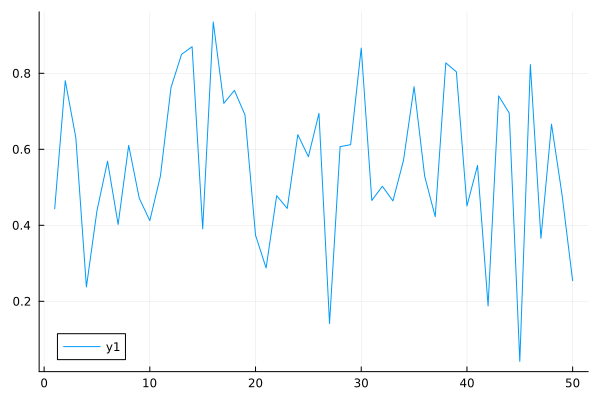

In [363]:
plot(rand(LogitNormal(.25), 50))

## Probabilistic Programming...